In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.transforms as transforms
import igraph as ig
import leidenalg as la
import numpy as np
from sklearn.neighbors import kneighbors_graph
import napypi
import matplotlib as mpl
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import os
os.chdir("../output/unsupervised")

In [16]:
dist_df = pd.read_csv("visualization_distance_preservation_results.csv")
clust_df = pd.read_csv("visualization_cluster_preservation_results.csv")
dist_df = dist_df[dist_df["K"]==10]
dist_df.drop(columns="K", inplace=True)

dist_df = dist_df.replace({"TCGA_LUAD": "TCGA-LUAD"})
clust_df = clust_df.replace({"TCGA_LUAD": "TCGA-LUAD"})

clust_df

,run,dim,method,silhouette,davies_bouldin,dataset
0,0,16,UMAP,0.292788,1.031001,HANCOCK
1,0,16,PCA,0.281478,0.991346,HANCOCK
2,0,16,tSNE,0.289531,0.990126,HANCOCK
3,1,16,UMAP,0.295198,0.979995,HANCOCK
4,1,16,PCA,0.203891,1.095567,HANCOCK
...,...,...,...,...,...,...
265,8,64,PCA,0.093654,2.706784,TCGA-LUAD
266,8,64,tSNE,0.262245,1.596045,TCGA-LUAD
267,9,64,UMAP,0.409399,0.753037,TCGA-LUAD
268,9,64,PCA,0.126729,2.246098,TCGA-LUAD


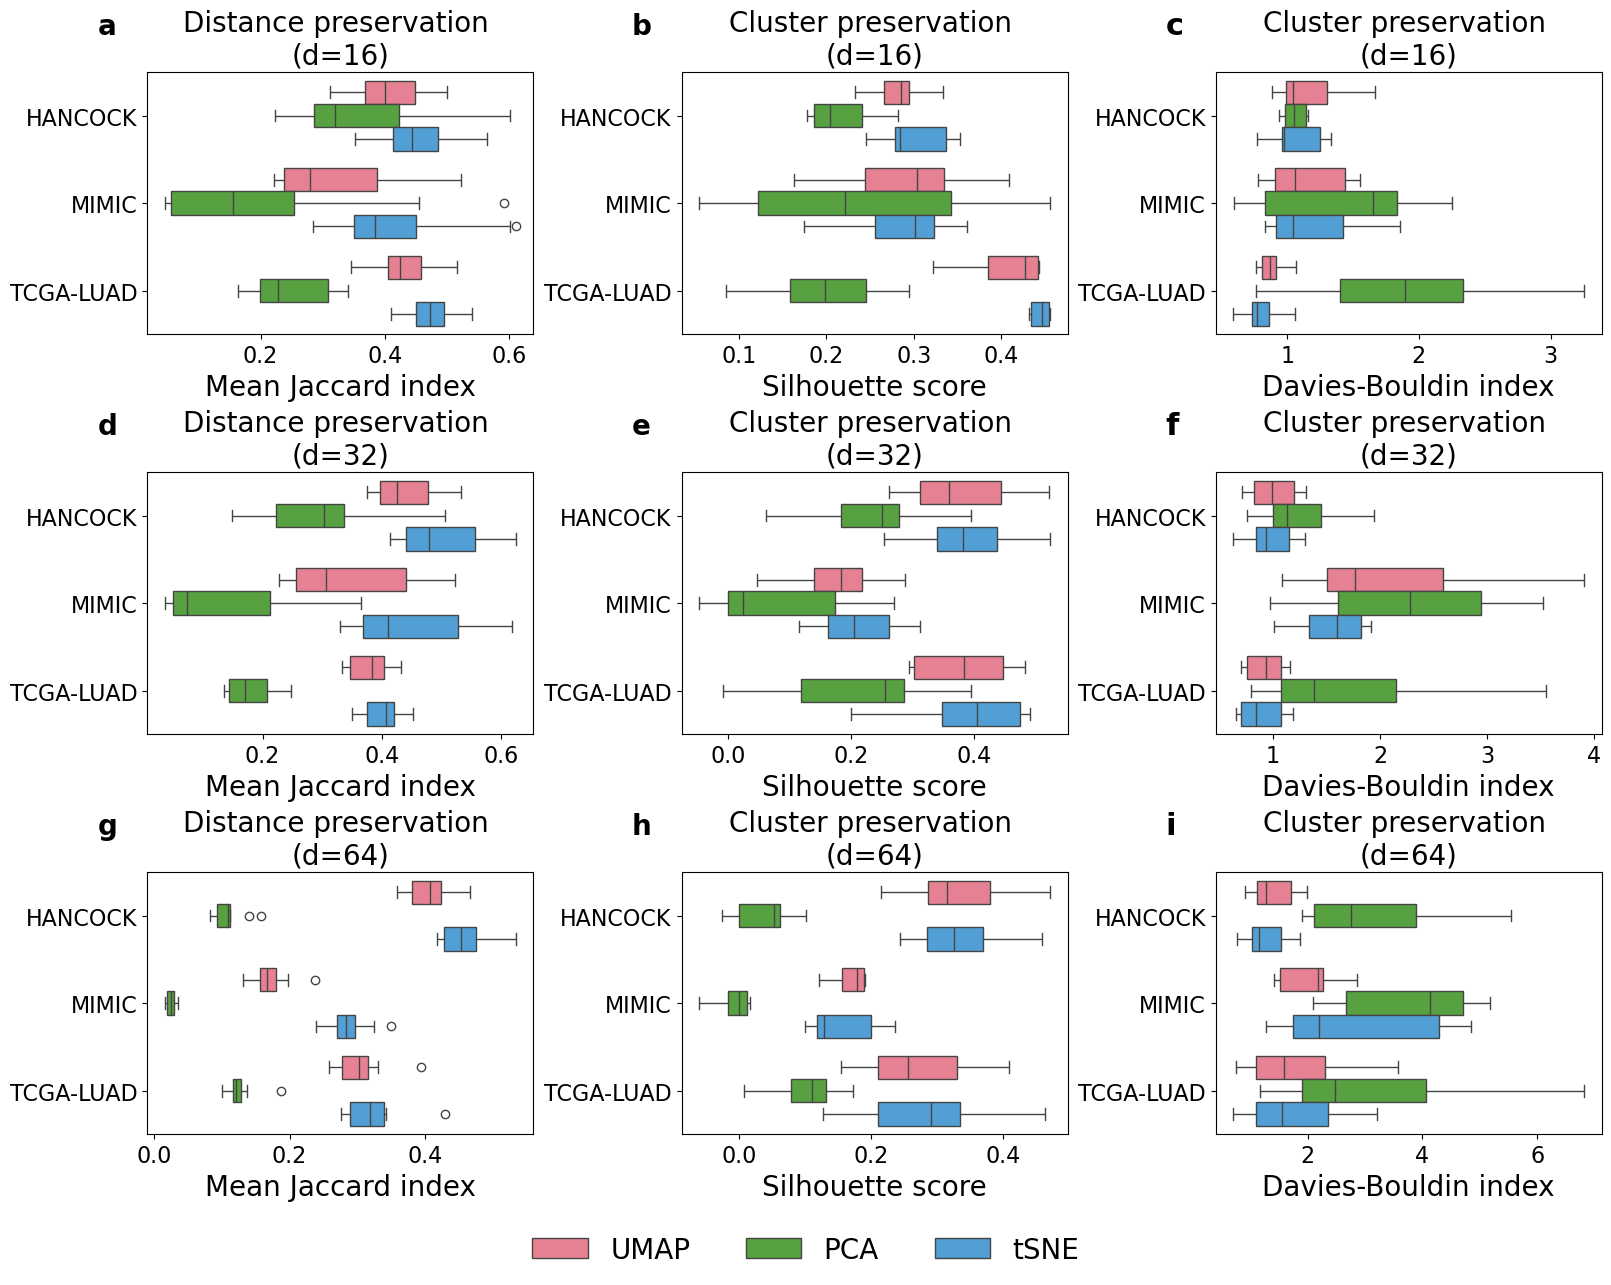

In [24]:
mosaic = [
['a', 'b', 'c'], ['d', 'e', 'f'], ['g', 'h', 'i']
]
fig, axes = plt.subplot_mosaic(mosaic, figsize=(16,12), layout='constrained')

labelfontsize = 20
titlefontsize = 20
ticklabelsize = 16
xylabelsize = 18
legendfontsize = 16
legendtitlefontsize = 18
offset = transforms.ScaledTranslation(-36 / 72, 27 / 72, fig.dpi_scale_trans)

sns.boxplot(data=dist_df[dist_df["dim"]==16], x="jaccard_index", y="dataset",
             hue="method", ax=axes["a"], legend=True, palette=sns.color_palette("husl", 3))
axes['a'].set_xlabel('Mean Jaccard index', fontsize=labelfontsize) 
axes['a'].set_ylabel('', fontsize=labelfontsize) 
axes['a'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['a'].tick_params(axis='y', labelsize=ticklabelsize)
axes['a'].text(0.0, 1.0, 'a', transform=axes['a'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')
axes['a'].set_title("Distance preservation \n(d=16)", fontsize=titlefontsize)

handles2, labels2 = axes["a"].get_legend_handles_labels()
axes["a"].legend_.remove()
legend2 = fig.legend(
    handles2, labels2,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.07),   # adjust vertically if needed
    ncol=len(labels2),
    fontsize=legendfontsize+4,
    frameon=False
)

sns.boxplot(data=dist_df[dist_df["dim"]==32], x="jaccard_index", y="dataset",
             hue="method", ax=axes["d"], legend=False, palette=sns.color_palette("husl", 3))
axes['d'].set_xlabel('Mean Jaccard index', fontsize=labelfontsize) 
axes['d'].set_ylabel('', fontsize=labelfontsize) 
axes['d'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['d'].tick_params(axis='y', labelsize=ticklabelsize)
axes['d'].text(0.0, 1.0, 'd', transform=axes['d'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')
axes['d'].set_title("Distance preservation \n(d=32)", fontsize=titlefontsize)

sns.boxplot(data=dist_df[dist_df["dim"]==64], x="jaccard_index", y="dataset",
             hue="method", ax=axes["g"], legend=False, palette=sns.color_palette("husl", 3))
axes['g'].set_xlabel('Mean Jaccard index', fontsize=labelfontsize) 
axes['g'].set_ylabel('', fontsize=labelfontsize) 
axes['g'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['g'].tick_params(axis='y', labelsize=ticklabelsize)
axes['g'].text(0.0, 1.0, 'g', transform=axes['g'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')
axes['g'].set_title("Distance preservation \n(d=64)", fontsize=titlefontsize)

sns.boxplot(data=clust_df[clust_df["dim"]==16], x="silhouette", y="dataset",
             hue="method", ax=axes["b"], legend=False, palette=sns.color_palette("husl", 3), showfliers=False)
axes['b'].set_xlabel('Silhouette score', fontsize=labelfontsize) 
axes['b'].set_ylabel('', fontsize=labelfontsize) 
axes['b'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['b'].tick_params(axis='y', labelsize=ticklabelsize)
axes['b'].set_title("Cluster preservation \n(d=16)", fontsize=titlefontsize)
axes['b'].text(0.0, 1.0, 'b', transform=axes['b'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.boxplot(data=clust_df[clust_df["dim"]==32], x="silhouette", y="dataset",
             hue="method", ax=axes["e"], legend=False, palette=sns.color_palette("husl", 3), showfliers=False)
axes['e'].set_xlabel('Silhouette score', fontsize=labelfontsize) 
axes['e'].set_ylabel('', fontsize=labelfontsize) 
axes['e'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['e'].tick_params(axis='y', labelsize=ticklabelsize)
axes['e'].set_title("Cluster preservation \n(d=32)", fontsize=titlefontsize)
axes['e'].text(0.0, 1.0, 'e', transform=axes['e'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.boxplot(data=clust_df[clust_df["dim"]==64], x="silhouette", y="dataset",
             hue="method", ax=axes["h"], legend=False, palette=sns.color_palette("husl", 3), showfliers=False)
axes['h'].set_xlabel('Silhouette score', fontsize=labelfontsize) 
axes['h'].set_ylabel('', fontsize=labelfontsize) 
axes['h'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['h'].tick_params(axis='y', labelsize=ticklabelsize)
axes['h'].set_title("Cluster preservation \n(d=64)", fontsize=titlefontsize)
axes['h'].text(0.0, 1.0, 'h', transform=axes['h'].transAxes + offset, fontsize=labelfontsize, fontweight='bold')

sns.boxplot(data=clust_df[clust_df["dim"]==16], x="davies_bouldin", y="dataset",
             hue="method", ax=axes["c"], legend=False, palette=sns.color_palette("husl", 3), showfliers=False)
axes['c'].set_xlabel('Davies-Bouldin index', fontsize=labelfontsize) 
axes['c'].set_ylabel('', fontsize=labelfontsize) 
axes['c'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['c'].tick_params(axis='y', labelsize=ticklabelsize)
axes['c'].set_title("Cluster preservation \n(d=16)", fontsize=titlefontsize)
axes['c'].text(0.0, 1.0, 'c', transform=axes['c'].transAxes + offset, fontsize=labelfontsize+2, fontweight='bold')

sns.boxplot(data=clust_df[clust_df["dim"]==32], x="davies_bouldin", y="dataset",
             hue="method", ax=axes["f"], legend=False, palette=sns.color_palette("husl", 3), showfliers=False)
axes['f'].set_xlabel('Davies-Bouldin index', fontsize=labelfontsize) 
axes['f'].set_ylabel('', fontsize=labelfontsize) 
axes['f'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['f'].tick_params(axis='y', labelsize=ticklabelsize)
axes['f'].set_title("Cluster preservation \n(d=32)", fontsize=titlefontsize)
axes['f'].text(0.0, 1.0, 'f', transform=axes['f'].transAxes + offset, fontsize=labelfontsize+2, fontweight='bold')

sns.boxplot(data=clust_df[clust_df["dim"]==64], x="davies_bouldin", y="dataset",
             hue="method", ax=axes["i"], legend=False, palette=sns.color_palette("husl", 3), showfliers=False)
axes['i'].set_xlabel('Davies-Bouldin index', fontsize=labelfontsize) 
axes['i'].set_ylabel('', fontsize=labelfontsize) 
axes['i'].tick_params(axis='x', labelsize=ticklabelsize) 
axes['i'].tick_params(axis='y', labelsize=ticklabelsize)
axes['i'].set_title("Cluster preservation \n(d=64)", fontsize=titlefontsize)
axes['i'].text(0.0, 1.0, 'i', transform=axes['i'].transAxes + offset, fontsize=labelfontsize+2, fontweight='bold')

plt.savefig("supplement_unsupervised_per_dimension.pdf", bbox_inches='tight', bbox_extra_artists=[legend2])